<a href="https://colab.research.google.com/github/kartiksingh0/Deep-Learning-assigment/blob/main/EarlyStopping.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [47]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles
from tensorflow.keras.layers import Dense
import seaborn as sns


In [48]:
X, y = make_circles(n_samples=100, noise=0.1, random_state=1)

<Axes: >

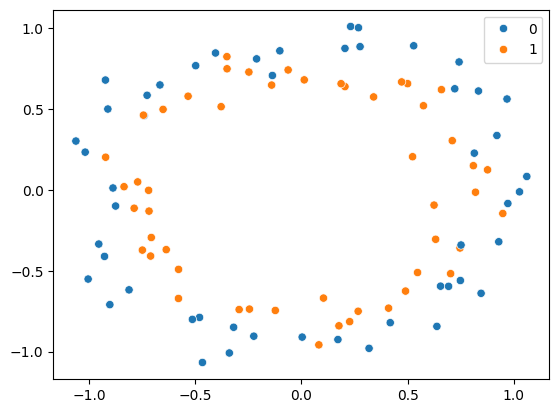

In [49]:
sns.scatterplot(x=X[:,0], y=X[:,1], hue=y)

In [50]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=2)

In [51]:
model = Sequential()
model.add(Dense(256,input_dim = 2,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [52]:
model.compile(loss= 'binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [53]:
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=3500, verbose=0)

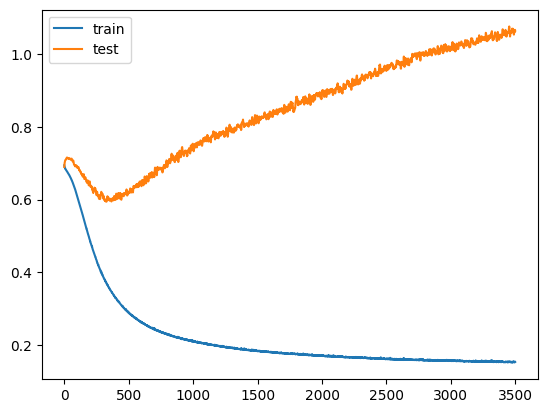

In [54]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

# **Early Stoping**

In [55]:
model = Sequential()

model.add(Dense(256, input_dim=2, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [56]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [57]:
callback = EarlyStopping(
    monitor="val_loss",
    min_delta=0.00001,
    patience=20,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=False
)

In [58]:
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=321,callbacks=callback)

Epoch 1/321
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 128ms/step - accuracy: 0.4750 - loss: 0.6922 - val_accuracy: 0.5000 - val_loss: 0.6926
Epoch 2/321
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5375 - loss: 0.6900 - val_accuracy: 0.4000 - val_loss: 0.6961
Epoch 3/321
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5125 - loss: 0.6891 - val_accuracy: 0.3500 - val_loss: 0.6993
Epoch 4/321
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5250 - loss: 0.6874 - val_accuracy: 0.3500 - val_loss: 0.7008
Epoch 5/321
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5375 - loss: 0.6863 - val_accuracy: 0.4500 - val_loss: 0.7022
Epoch 6/321
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5375 - loss: 0.6857 - val_accuracy: 0.4000 - val_loss: 0.7041
Epoch 7/321
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5500 - loss: 0.6845 - val_accuracy: 0.4000 - val_loss: 0.7053
Epoch 8/321
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5750 - loss: 0.6834 - val_accuracy: 0.4500 - val_loss

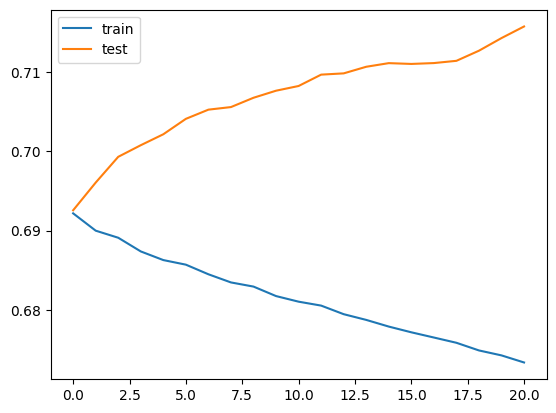

In [59]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()